In [1]:
import pandas as pd
import math
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import matplotlib
import ast

In [2]:
MAPT_predictions = pd.read_csv("../data/Kumar_2022_MAPT_SplicingPredictions.csv.gz")

In [3]:
# SpliceAI
MAPT_predictions["spliceai_avg"] = (
    MAPT_predictions["spliceai_acceptor"] + MAPT_predictions["spliceai_donor"]
) / 2

# Pangolin
pangolin_tissues = ["testis", "heart", "liver", "brain"]
for tissue in pangolin_tissues:
    acc_alt = f"pangolin_{tissue}_usage_acceptor_alt"
    don_alt = f"pangolin_{tissue}_usage_donor_alt"
    
    acc = f"pangolin_{tissue}_usage_acceptor"
    don = f"pangolin_{tissue}_usage_donor"
    avg = f"pangolin_{tissue}_usage_avg"

    MAPT_predictions[acc] = MAPT_predictions[acc_alt]
    MAPT_predictions[don] = MAPT_predictions[don_alt]
    MAPT_predictions[avg] = (MAPT_predictions[acc] + MAPT_predictions[don]) / 2

pangolin_avg_cols = [f"pangolin_{t}_usage_avg" for t in pangolin_tissues]
MAPT_predictions["pangolin_all_tissues_avg"] = MAPT_predictions[pangolin_avg_cols].mean(axis=1)

In [4]:
# SpliceAI error
MAPT_predictions["spliceai_avg_error"] = (
    MAPT_predictions["spliceai_avg"] - MAPT_predictions["PSI"]
)

# Pangolin errors for each tissue
for tissue in pangolin_tissues:
    avg = f"pangolin_{tissue}_usage_avg"
    err = f"{avg}_error"
    MAPT_predictions[err] = MAPT_predictions[avg] - MAPT_predictions["PSI"]

# Average pangolin error
MAPT_predictions["pangolin_all_tissues_avg_error"] = (
    MAPT_predictions["pangolin_all_tissues_avg"] - MAPT_predictions["PSI"]
)

# AlphaGenome error
MAPT_predictions["alphagenome_junctions_psi_error"] = (
    MAPT_predictions["alphagenome_junctions_psi"] - MAPT_predictions["PSI"]
)

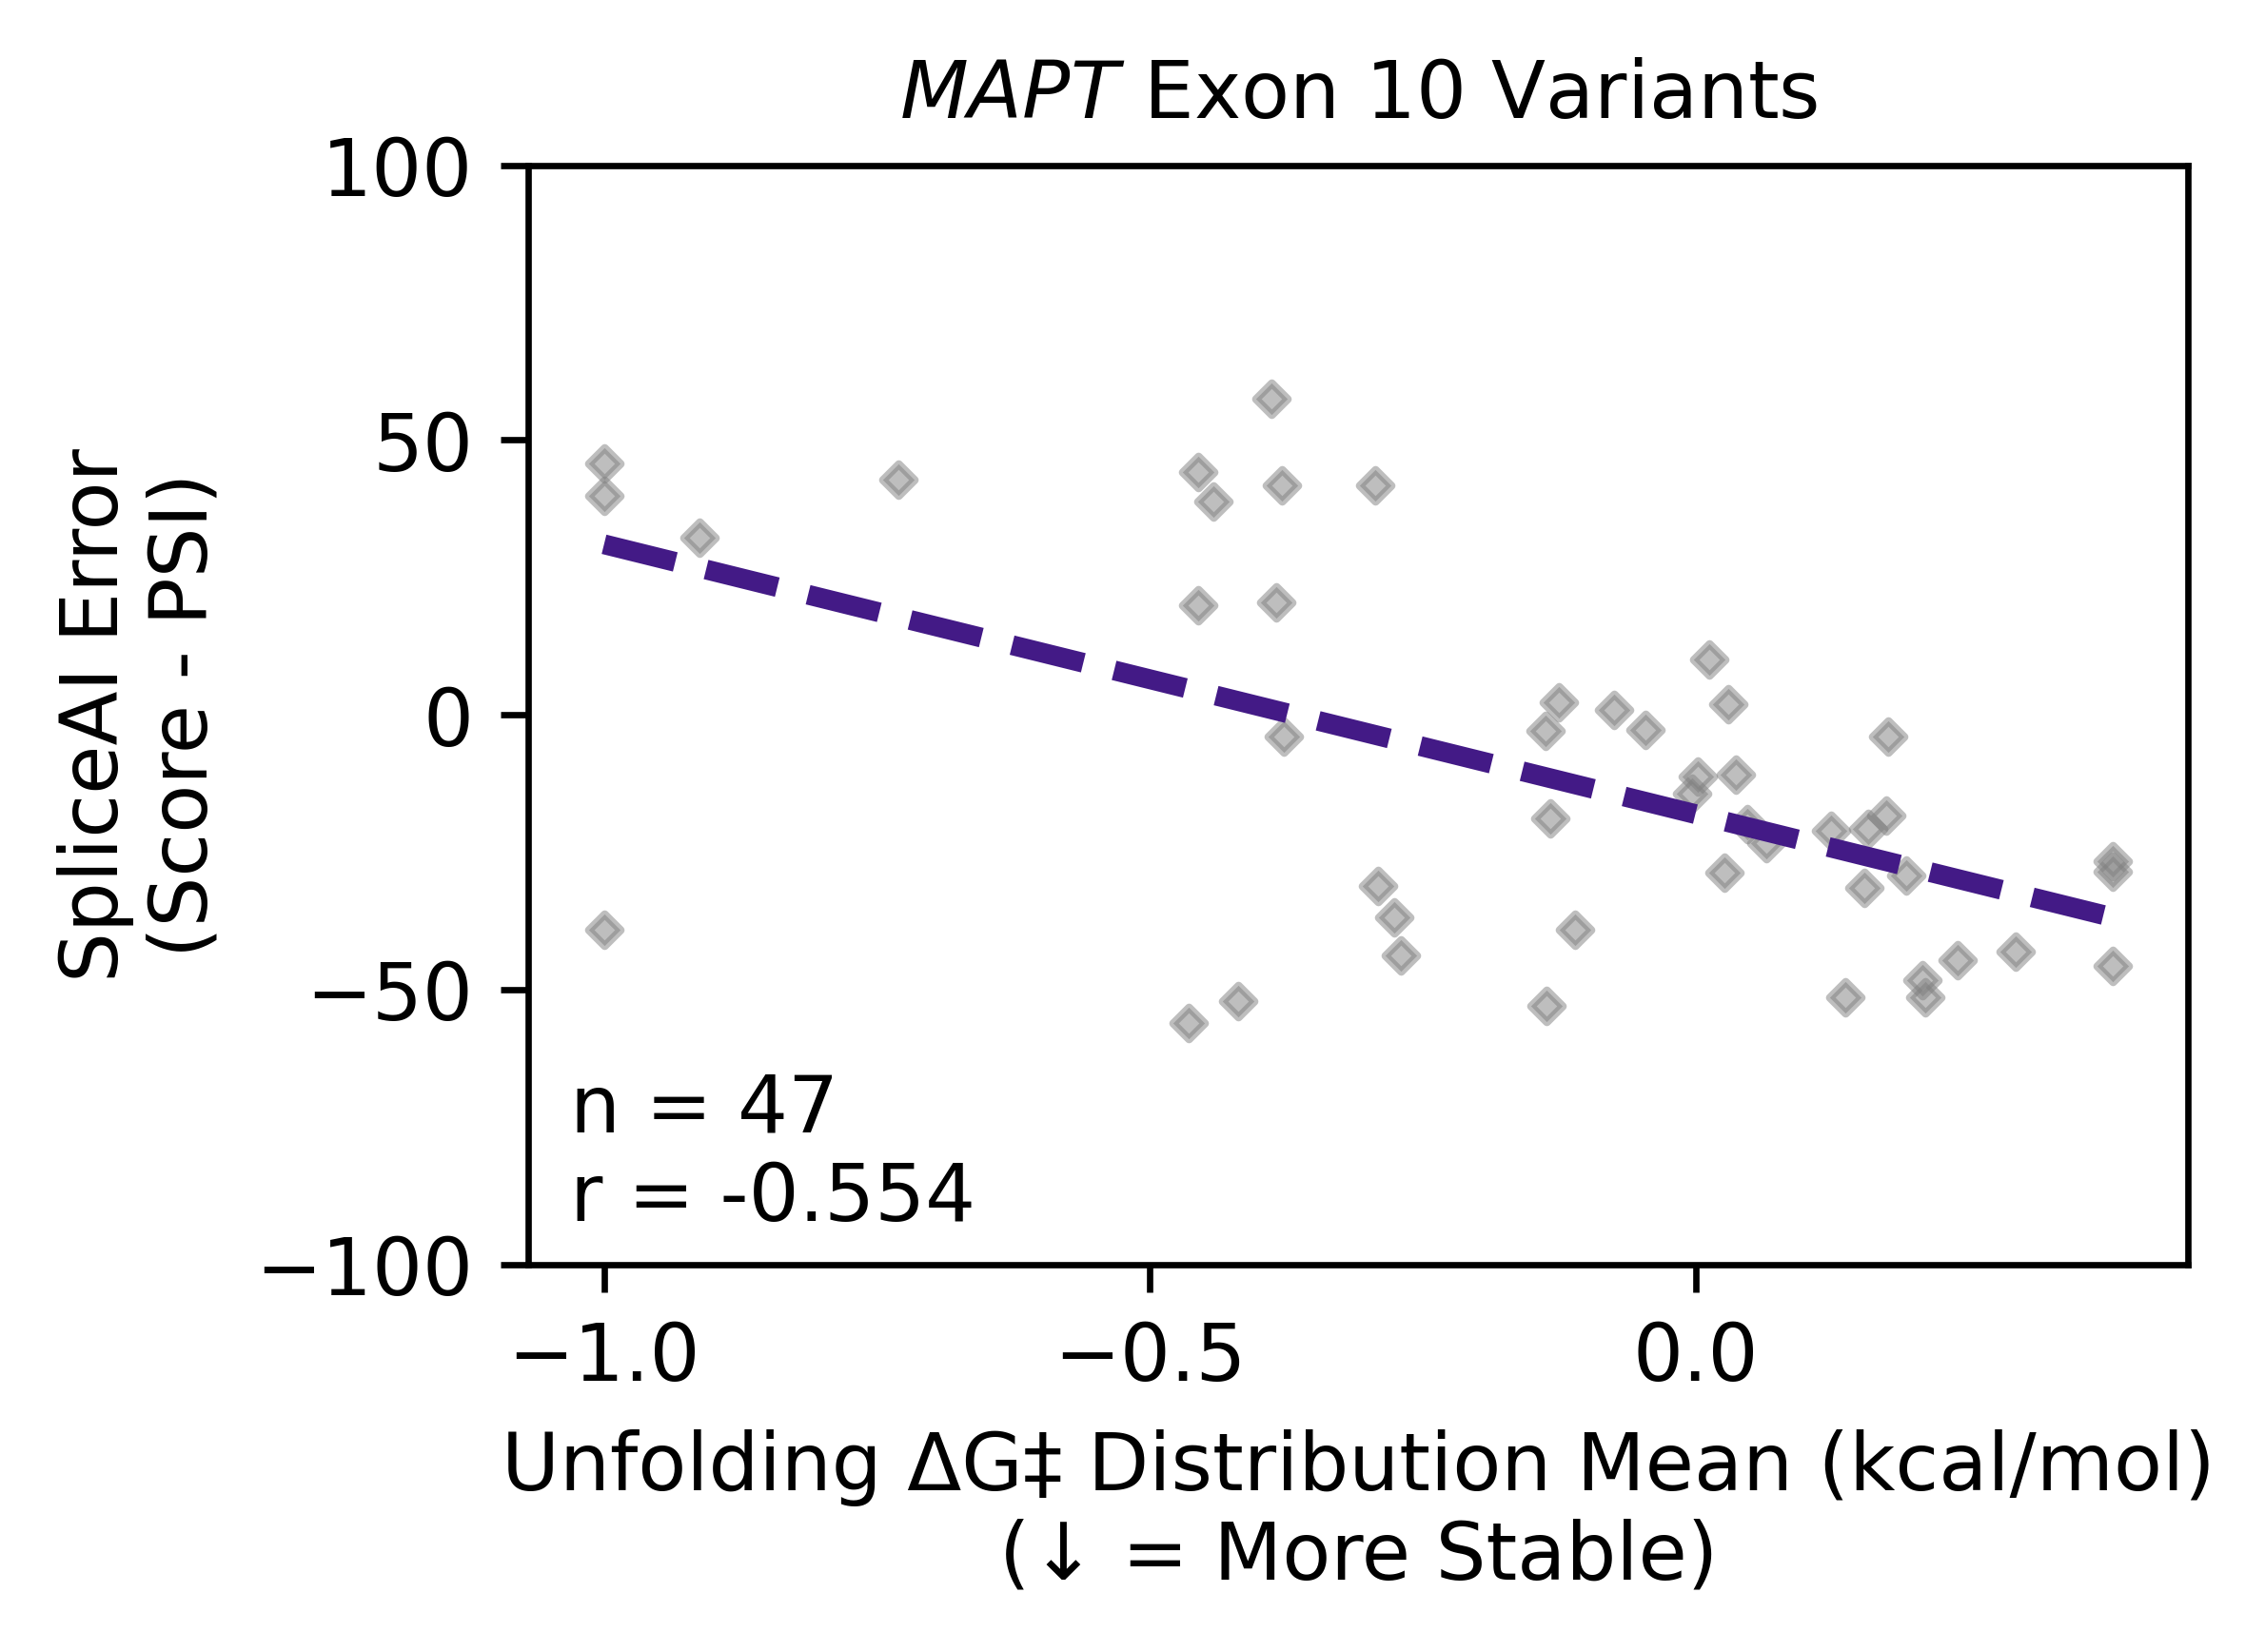

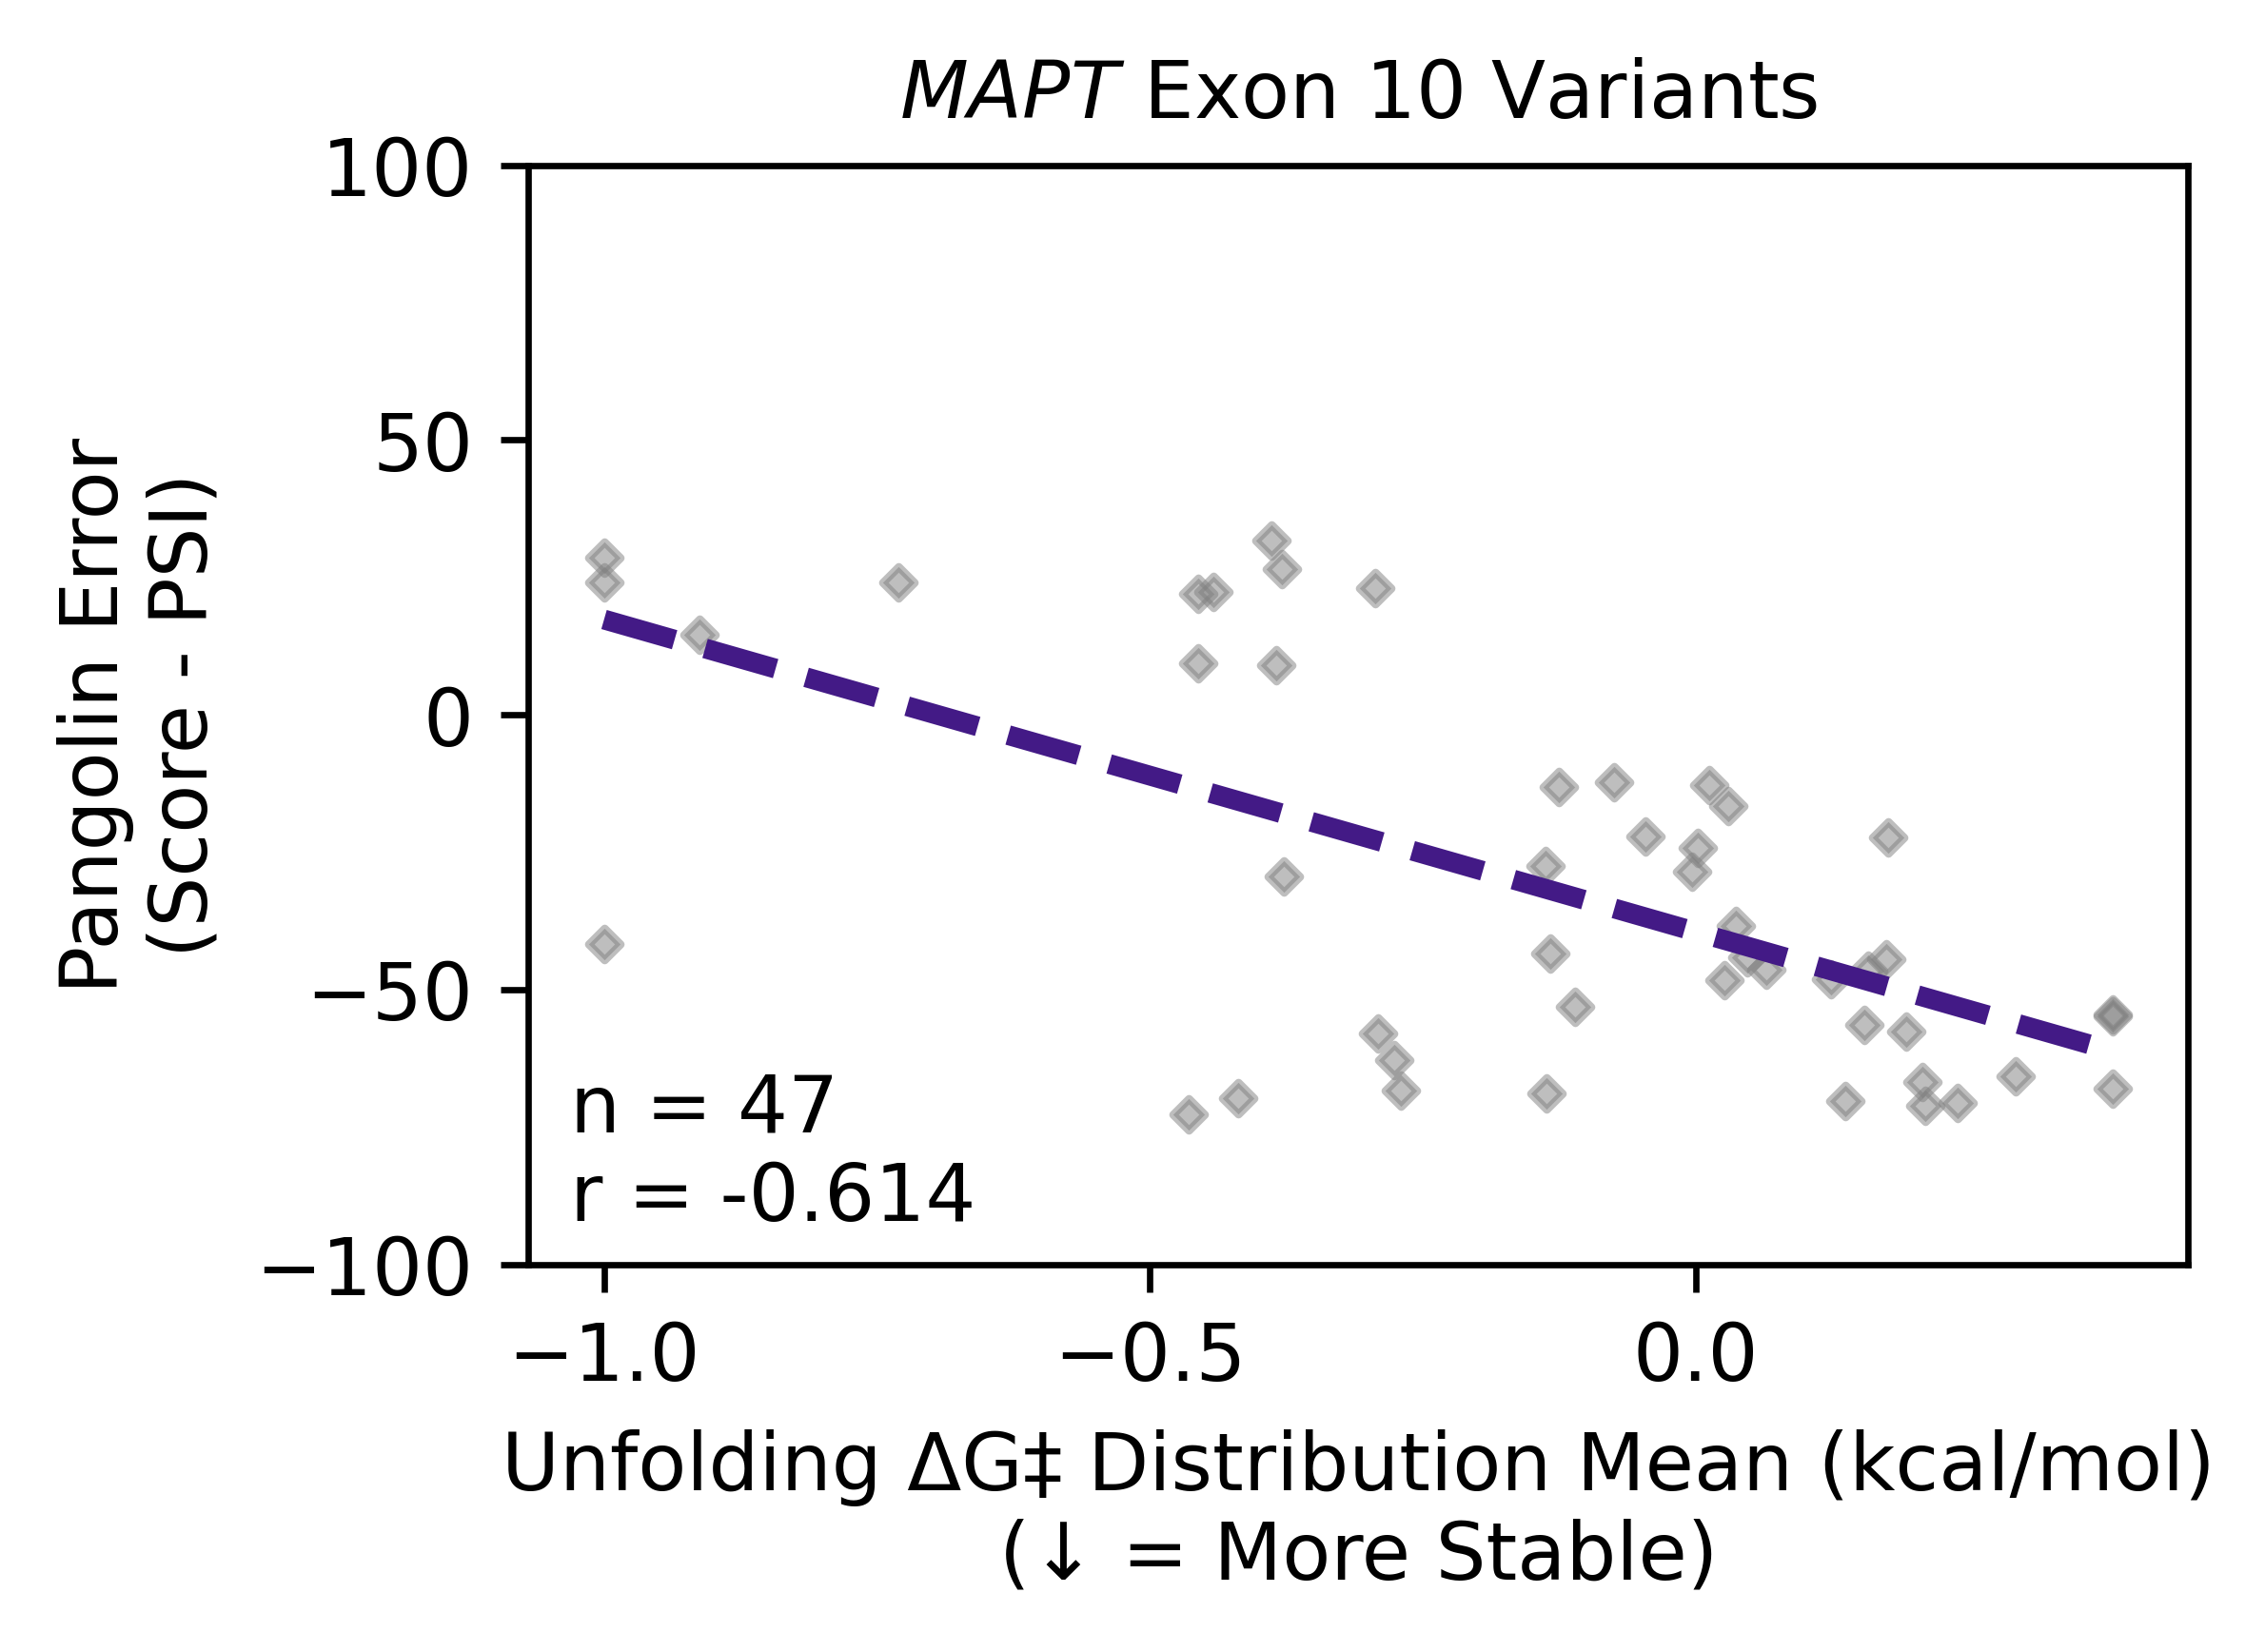

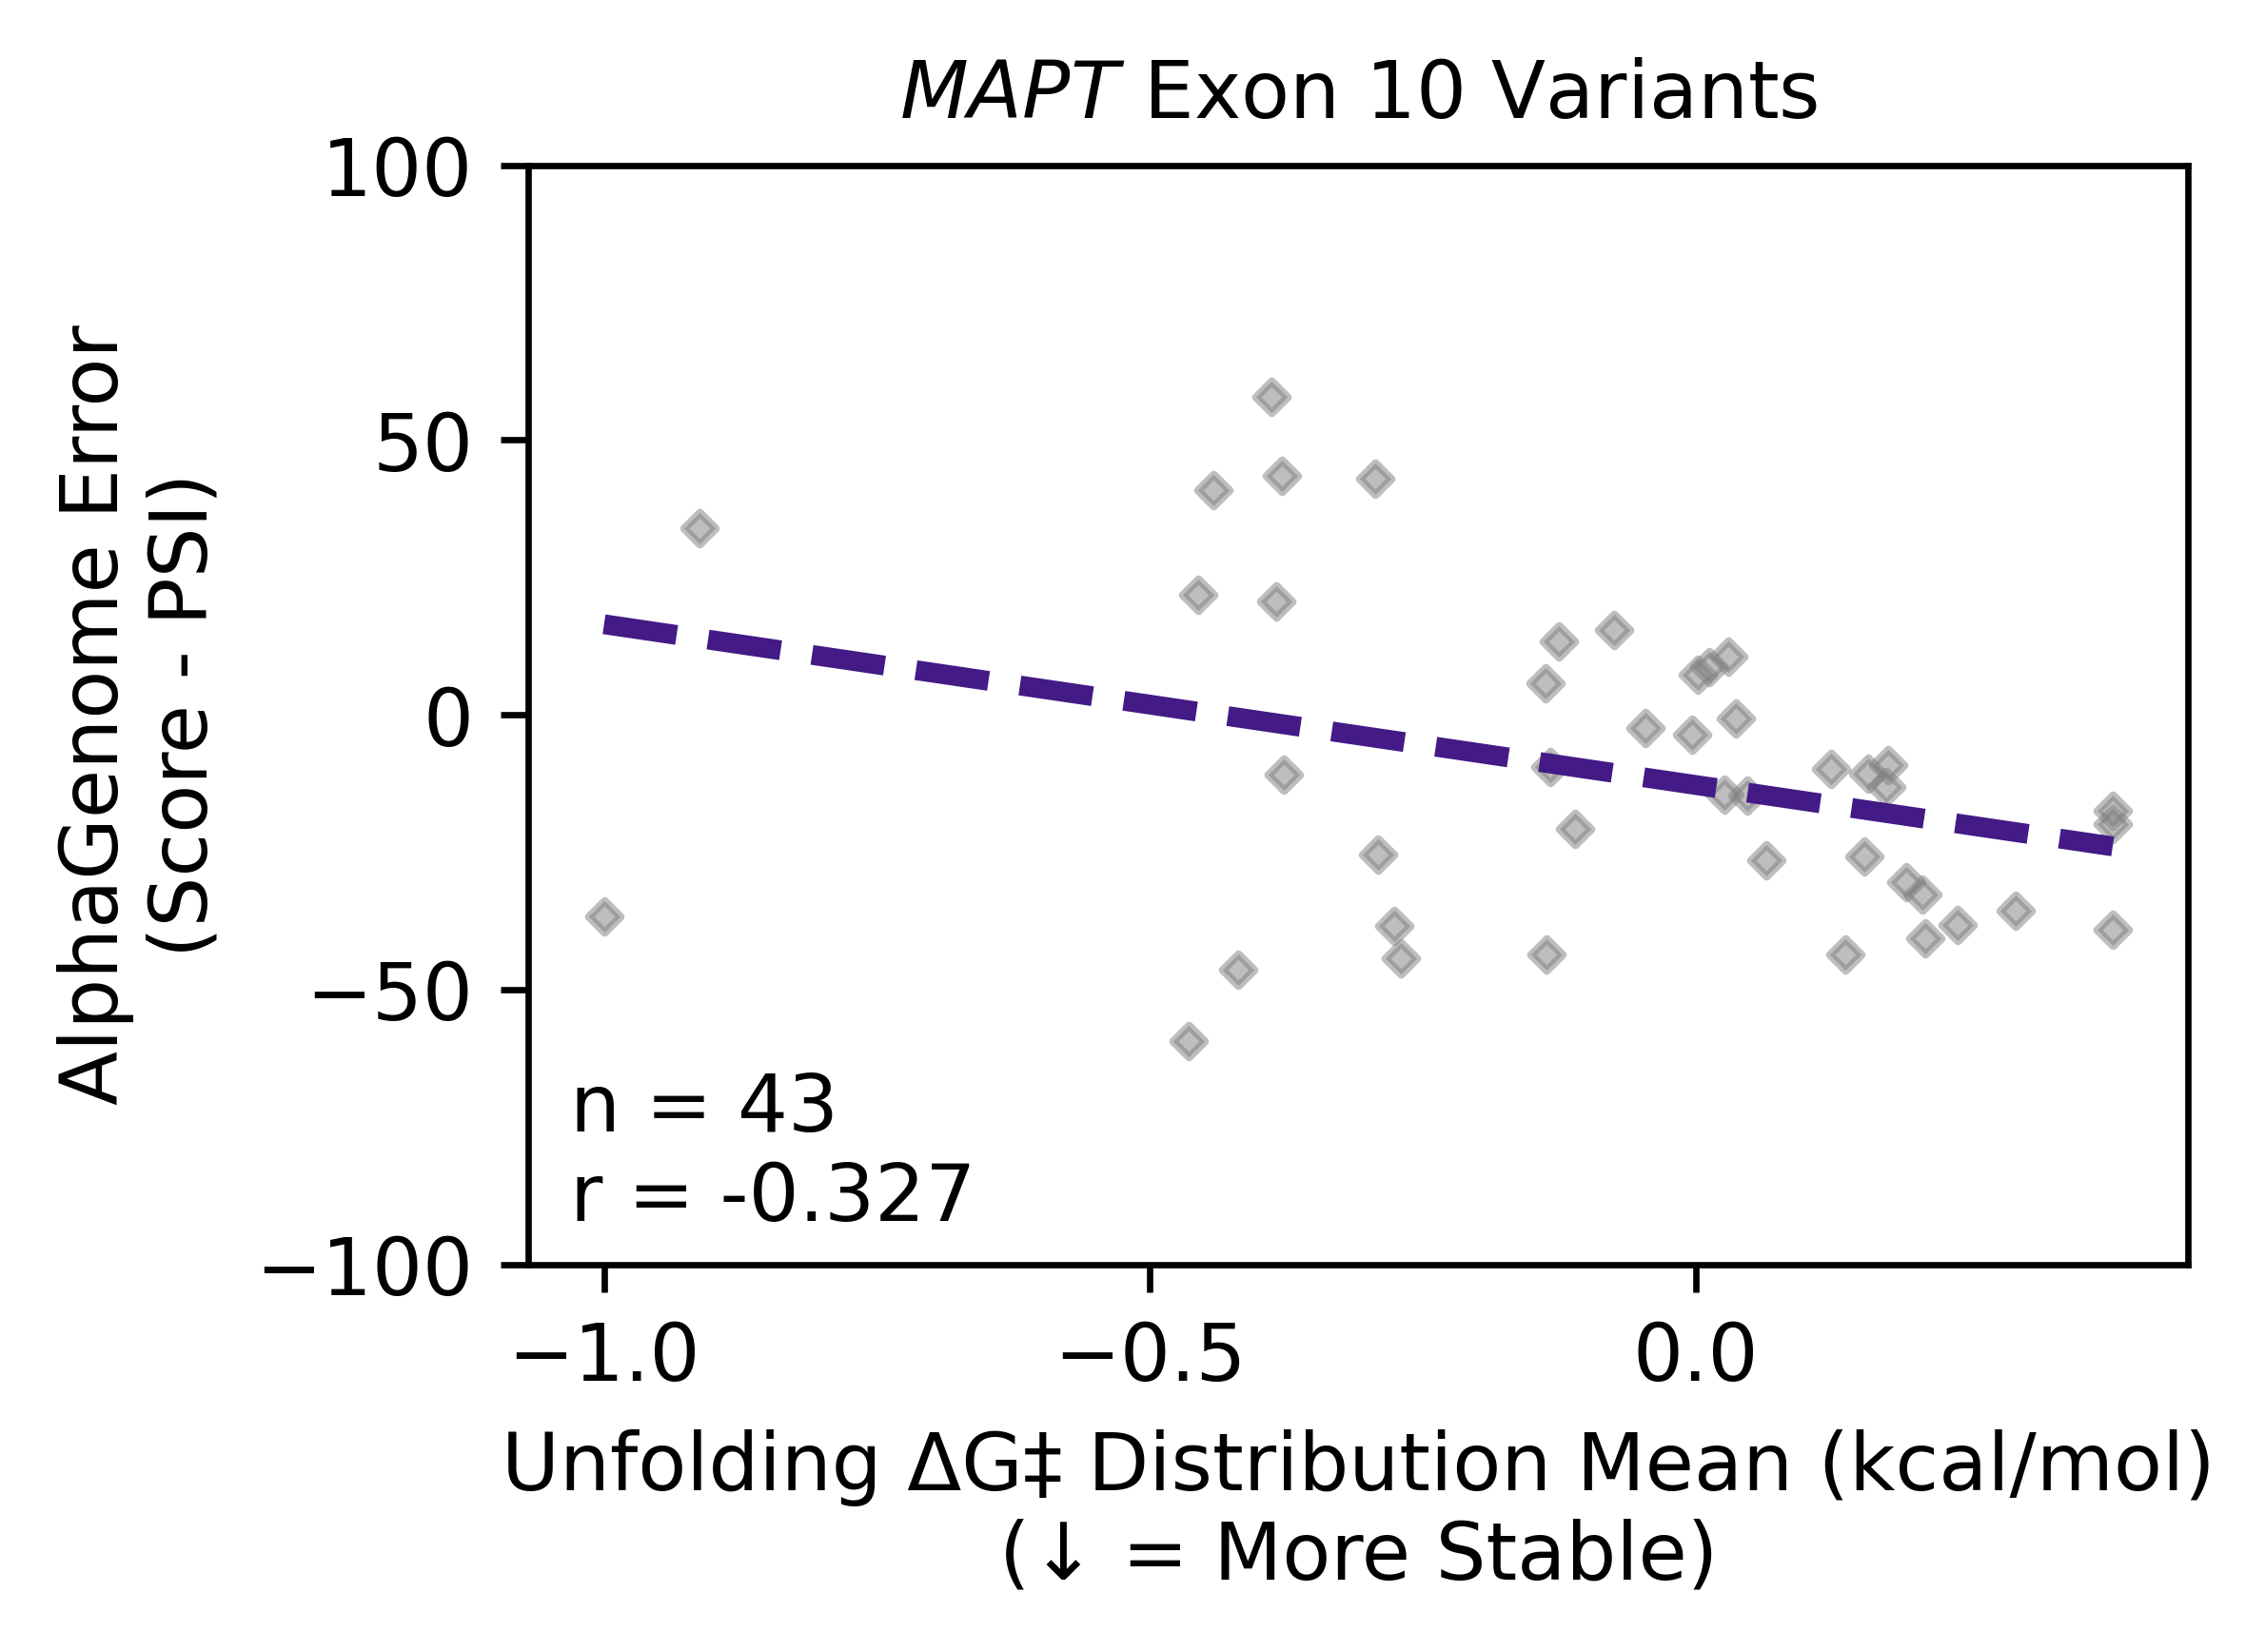

In [5]:
#fontsize=7
fontsize=10

models = {
    "SpliceAI": "spliceai_avg_error",
    "Pangolin": "pangolin_all_tissues_avg_error",
    "AlphaGenome": "alphagenome_junctions_psi_error", 
}

x = pd.to_numeric(MAPT_predictions["strucMean"], errors="coerce")

for model_name, err_col in models.items():
    y = pd.to_numeric(MAPT_predictions[err_col], errors="coerce") * 100

    # Mask NaNs
    mask = ~(x.isna() | y.isna())
    xx_raw = x[mask].values
    yy_raw = y[mask].values

    # Regression
    m, b = np.polyfit(xx_raw, yy_raw, 1)
    xx_line = np.linspace(xx_raw.min(), xx_raw.max(), 200)
    yy_line = m * xx_line + b
    pearson = stats.linregress(xx_raw, yy_raw)

    #fig, ax = plt.subplots(figsize=(2.8, 2.25), dpi=600)
    fig, ax = plt.subplots(figsize=(3.75, 2.5), dpi=600)

    ax.scatter(xx_raw, yy_raw, color="tab:grey", alpha=0.5, s=8, marker="D")
    ax.plot(xx_line, yy_line, color="#431a86", linewidth=2.5, linestyle="dashed")

    ax.set_xlabel("Unfolding ΔG‡ Distribution Mean (kcal/mol)\n(↓ = More Stable)", fontsize=fontsize)
    ax.set_ylabel(f"{model_name} Error\n(Score - PSI)", fontsize=fontsize)
    ax.set_ylim(-100, 100)
    ax.set_title(r"$MAPT$ Exon 10 Variants", fontsize=fontsize)

    ax.tick_params(axis='x', labelsize=fontsize)
    ax.tick_params(axis='y', labelsize=fontsize)

    ax.text(0.025, 0.025, f"n = {len(xx_raw)}\nr = {pearson.rvalue:.3f}", transform=ax.transAxes,
                va="bottom", ha="left", fontsize=fontsize)

    fig.savefig(f"figures/MAPT_structMean_{err_col}.svg", dpi=600, bbox_inches="tight")
    plt.show()